In [7]:
# Import libraries and load dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

print("Current Directory:", os.getcwd())

df = pd.read_csv("dataset/sleep.csv")
df.head()

Current Directory: c:\Users\kavya\Projects\Data Science\Data Cleaning & Visualization Project


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [8]:
# Explore dataset structure, statistics, and missing values

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [9]:
# Clean dataset by renaming columns, handling missing values, and removing duplicates

df.columns = df.columns.str.strip().str.replace(" ", "_")
df.fillna(df.median(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

df.isnull().sum()
df.shape

(374, 13)

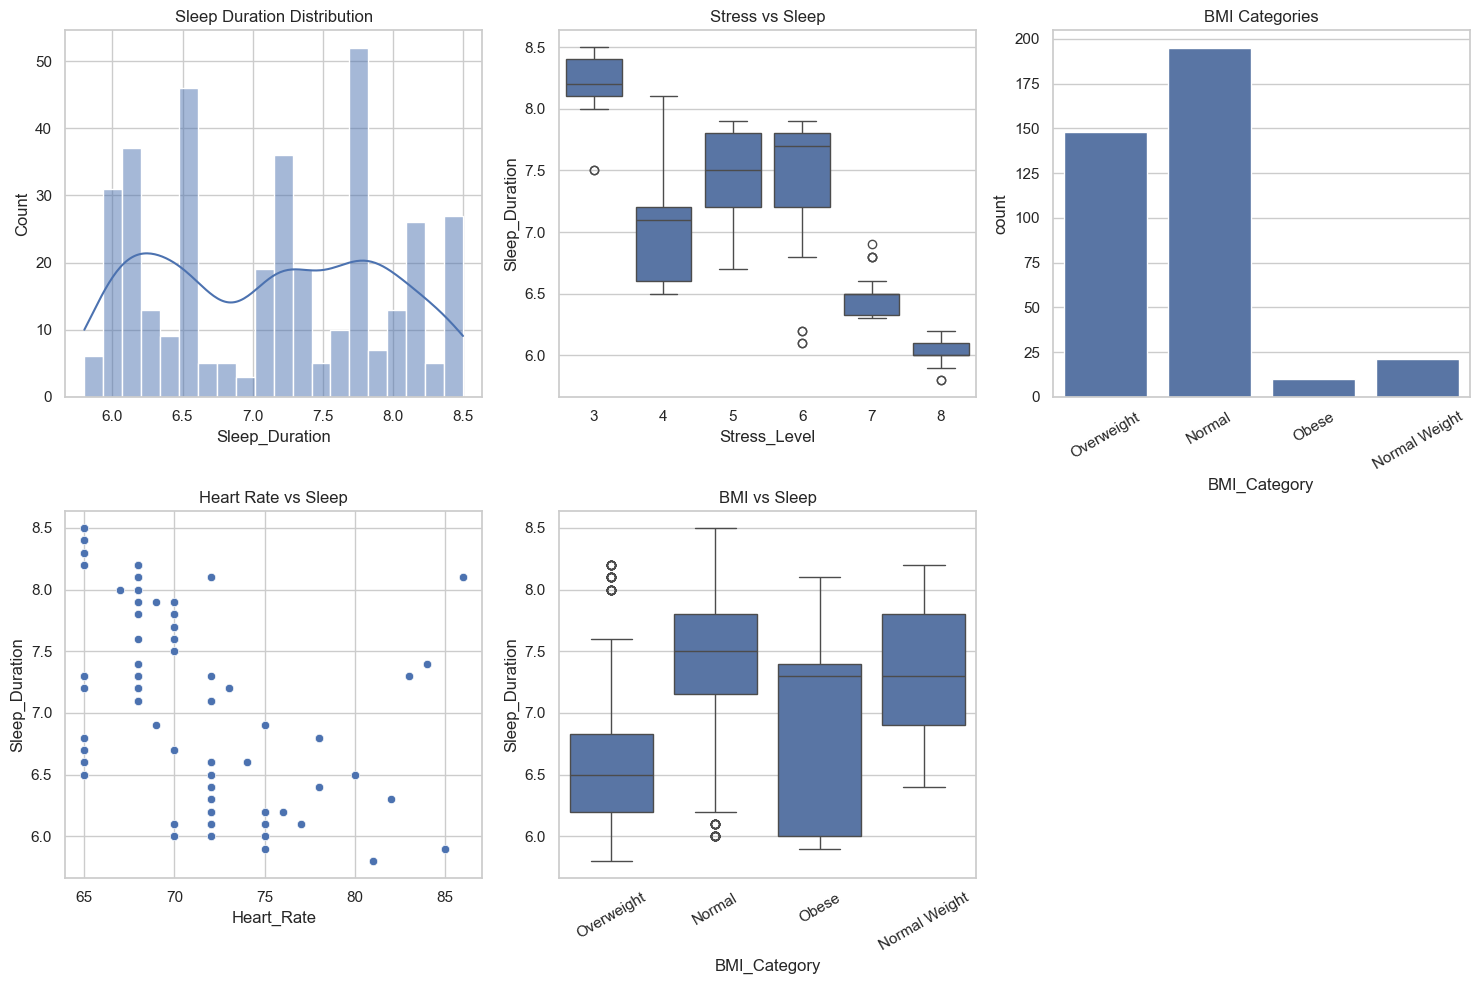

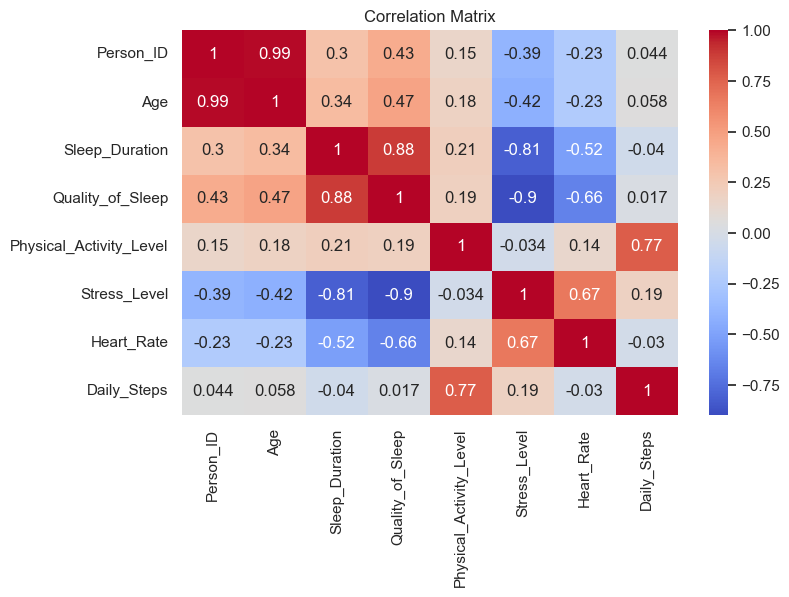

In [10]:
# Create visualizations to analyze sleep patterns and relationships

plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
sns.histplot(df['Sleep_Duration'], bins=20, kde=True)
plt.title("Sleep Duration Distribution")

plt.subplot(2,3,2)
sns.boxplot(x='Stress_Level', y='Sleep_Duration', data=df)
plt.title("Stress vs Sleep")

plt.subplot(2,3,3)
sns.countplot(x='BMI_Category', data=df)
plt.xticks(rotation=30)
plt.title("BMI Categories")

plt.subplot(2,3,4)
sns.scatterplot(x='Heart_Rate', y='Sleep_Duration', data=df)
plt.title("Heart Rate vs Sleep")

plt.subplot(2,3,5)
sns.boxplot(x='BMI_Category', y='Sleep_Duration', data=df)
plt.xticks(rotation=30)
plt.title("BMI vs Sleep")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
# Display key insights and save cleaned dataset

print("Key Insights:")
print("1. Higher stress levels are associated with lower sleep duration.")
print("2. People with normal BMI tend to have better sleep patterns.")
print("3. Heart rate shows slight negative relation with sleep.")
print("4. Sleep duration varies across BMI categories.")
print("5. Lifestyle factors influence sleep quality significantly.")

df.to_csv("cleaned_sleep_data.csv", index=False)

Key Insights:
1. Higher stress levels are associated with lower sleep duration.
2. People with normal BMI tend to have better sleep patterns.
3. Heart rate shows slight negative relation with sleep.
4. Sleep duration varies across BMI categories.
5. Lifestyle factors influence sleep quality significantly.
